# “Which machine learning models perform best in predicting a target variable using a real-world dataset, and how do feature engineering and hyperparameter optimisation influence their performance?”

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Load Dataset

In [72]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Info

In [73]:
print("Dataset shape:", df.shape)
df.info()
df.columns

Dataset shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Target Variable Distribution

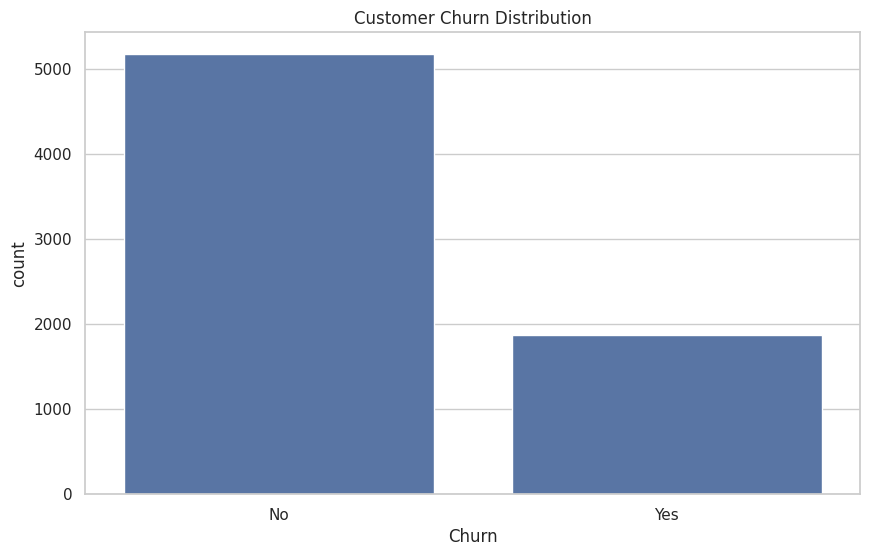

In [74]:
df["Churn"].value_counts()
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.savefig("churn_distribution.png")
plt.show()

### Missing Value Analysis

In [75]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [76]:
# Checking TotalCharges column
df["TotalCharges"].value_counts().head()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8


### Distribution of Numerical Variables

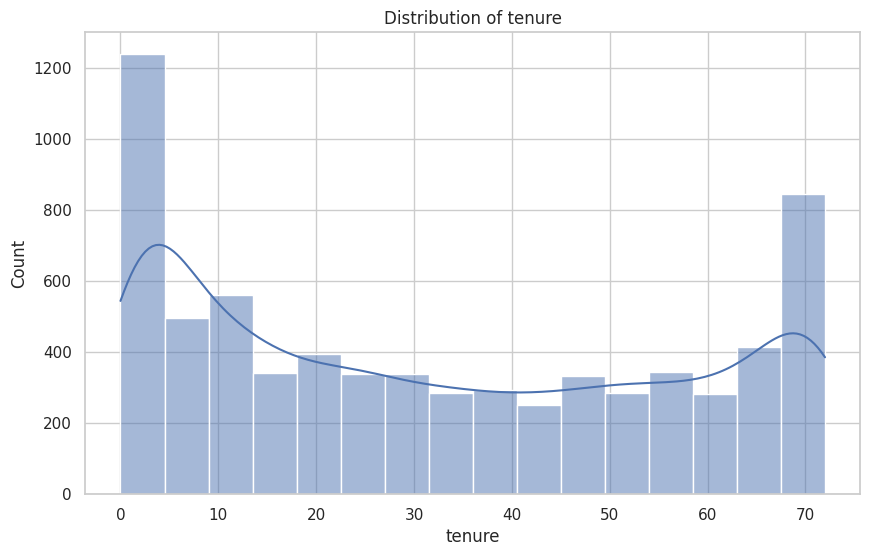

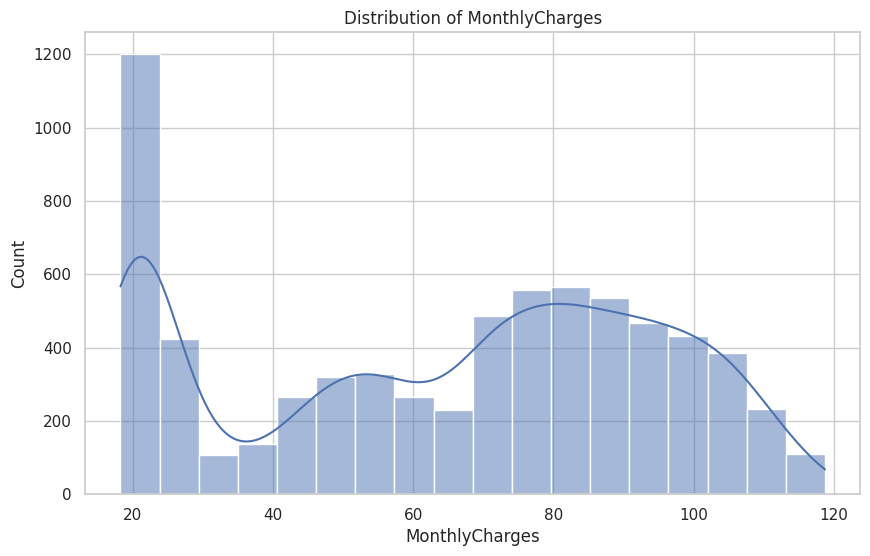

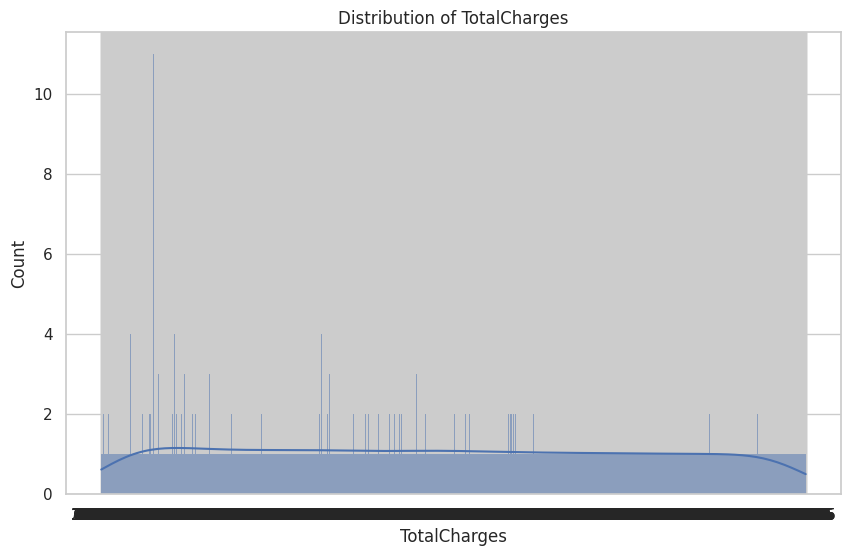

In [77]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.savefig(f"{col}_distribution.png")
    plt.show()

### Churn vs Tenure

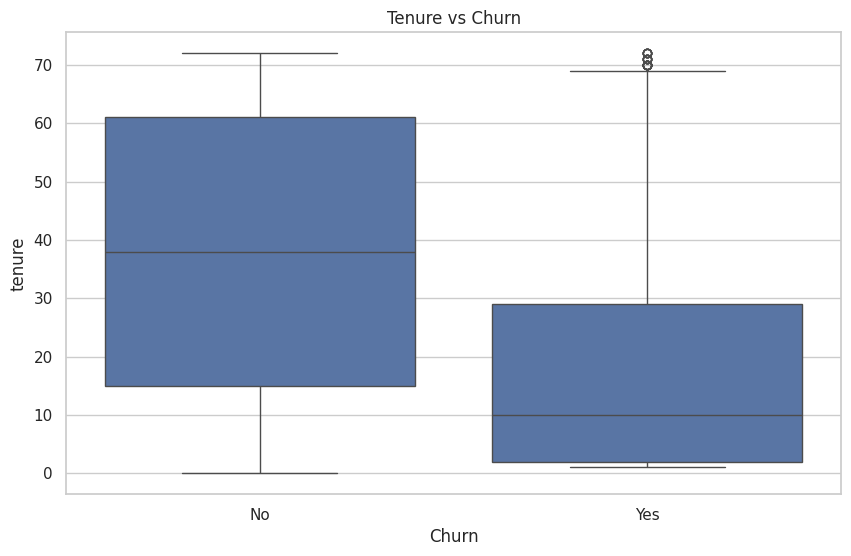

In [78]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.savefig("churn_vs_tenure.png")
plt.show()


### Churn vs Monthly Charges

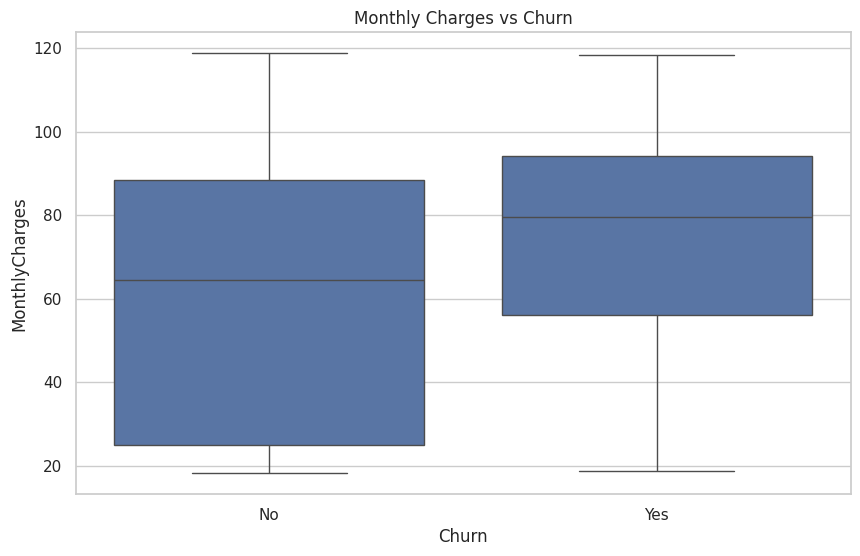

In [79]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.savefig("churn_vs_monthly_charges.png")
plt.show()

### Contract Type vs Churn

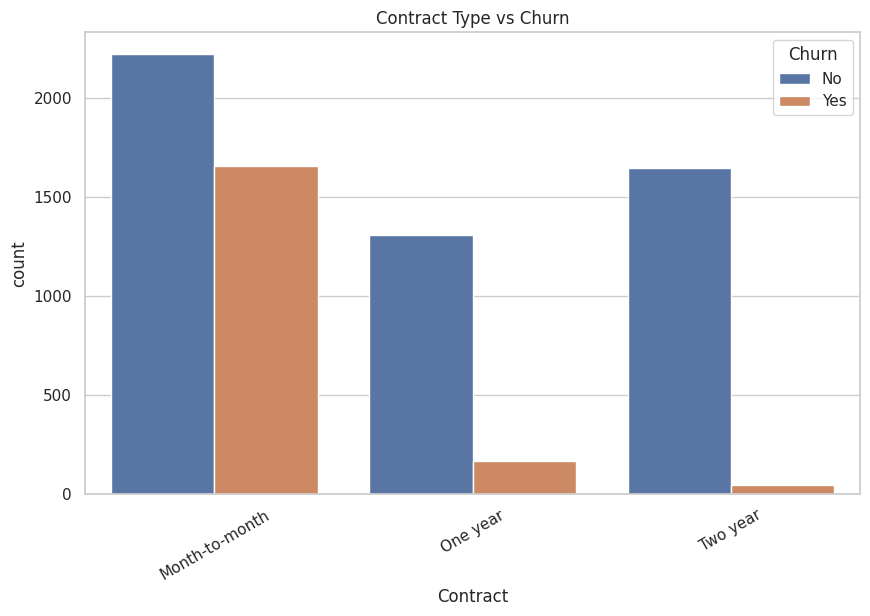

In [80]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type vs Churn")
plt.xticks(rotation=30)
plt.savefig("contract_vs_churn.png")
plt.show()

### Correlation Analysis

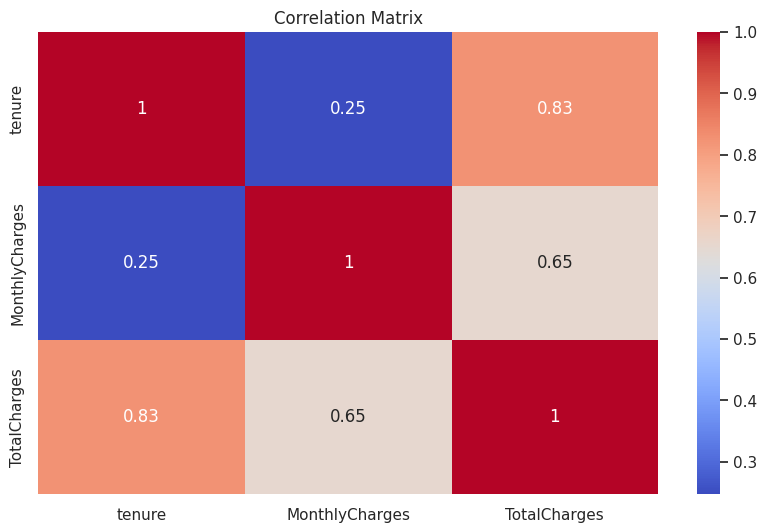

In [81]:
# Convert TotalCharges to numeric safely
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

corr = df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix.png")
plt.show()


## Preprocessing

In [82]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_1055/617195598.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


### Drop the Unnecessary column

In [83]:
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

### Encode Target Variable

In [84]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

### Encode Categorical Variables

In [85]:
df = pd.get_dummies(df, drop_first=True)

### Feature Engineering

In [86]:
# Avg Charges
df["AvgCharges"] = df["TotalCharges"] / (df["tenure"] + 1)

#  Total Services
service_cols = [col for col in df.columns if any(keyword in col for keyword in [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
])]

df["TotalServices"] = df[service_cols].sum(axis=1)

# High Spender
df["HighSpender"] = (df["MonthlyCharges"] > df["MonthlyCharges"].median()).astype(int)

#  Contract Risk
# After encoding → Contract_Month-to-month exists
if "Contract_Month-to-month" in df.columns:
    df["IsMonthlyContract"] = df["Contract_Month-to-month"]

print("Feature Engineering Completed Successfully")

Feature Engineering Completed Successfully


#### Train–Test Split

In [87]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5634, 33)
Test size: (1409, 33)


Feature Scaling

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

#### Logistic Regression

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



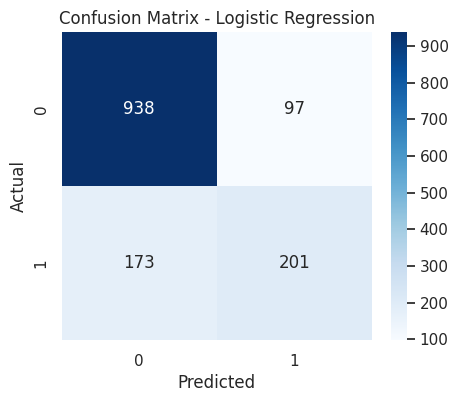

In [90]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix_log.png")
plt.show()

#### Random Forest

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



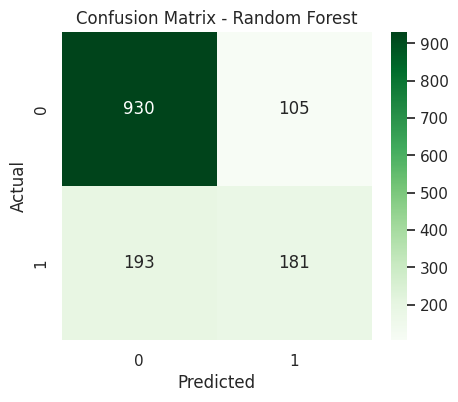

In [91]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix_rf.png")
plt.show()

XGBoost

XGBoost Results

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8235


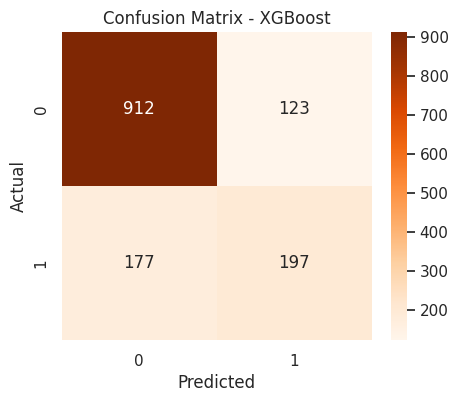

In [92]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results\n")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb), 4))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix_xgb.png")
plt.show()

Create Model Comparison Table

In [93]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.808375,0.674497,0.537433,0.598214,0.846638
1,Random Forest,0.788502,0.632867,0.483957,0.548485,0.824886
2,XGBoost,0.787083,0.615625,0.526738,0.567723,0.823458


Model Comparison Plot

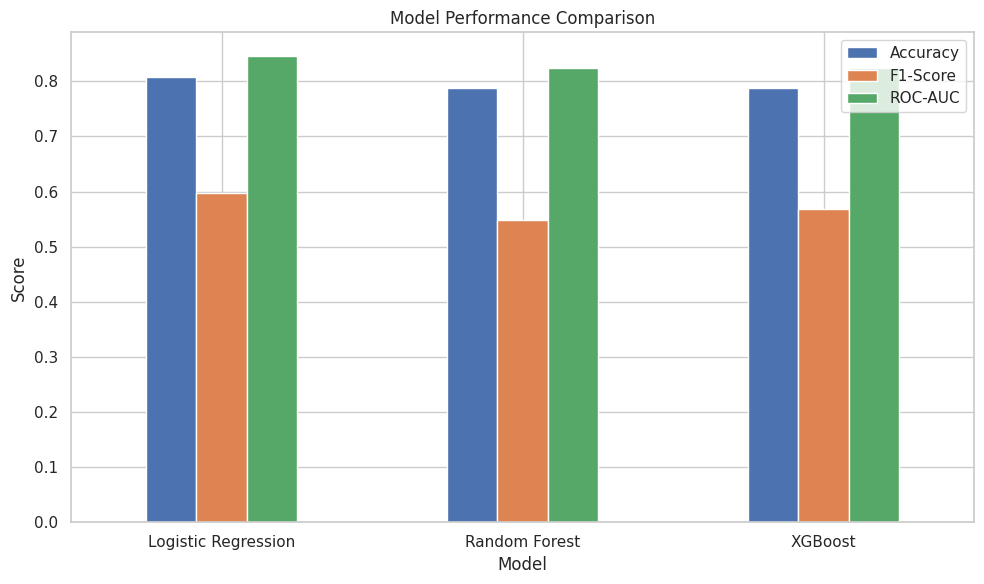

In [94]:
import matplotlib.pyplot as plt

results.set_index("Model")[["Accuracy", "F1-Score", "ROC-AUC"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

ROC Curve Comparison

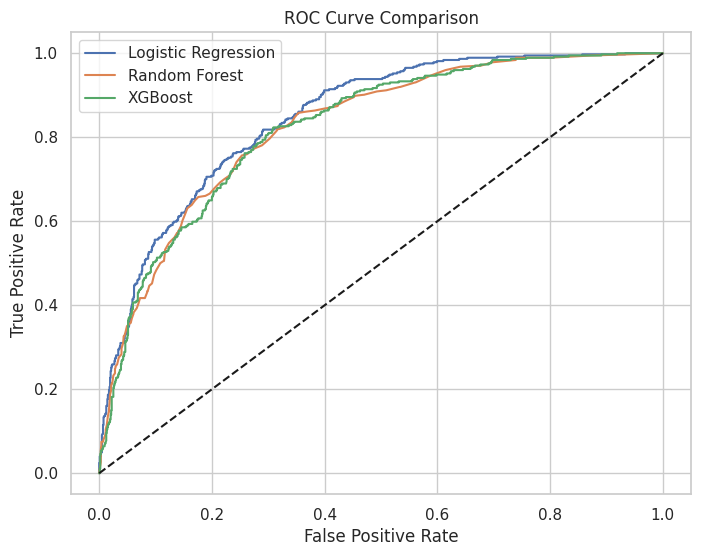

In [95]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name, probs in [
    ("Logistic Regression", y_prob_log),
    ("Random Forest", y_prob_rf),
    ("XGBoost", y_prob_xgb)
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("roc_curve_comparison.png")
plt.show()


### Cross Validation

In [96]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=42), X_train_scaled),
    "Random Forest": (RandomForestClassifier(random_state=42), X_train),
    "XGBoost": (XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss"), X_train)
}

cv_results = []

for name, (model, X_data) in models.items():
    scores = cross_validate(
        model,
        X_data,
        y_train,
        cv=skf,
        scoring=["accuracy", "f1"],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV Accuracy": np.mean(scores["test_accuracy"]),
        "Mean CV F1": np.mean(scores["test_f1"]),
        "Std Accuracy": np.std(scores["test_accuracy"]),
        "Std F1": np.std(scores["test_f1"])
    })

cv_df = pd.DataFrame(cv_results)
cv_df

,Model,Mean CV Accuracy,Mean CV F1,Std Accuracy,Std F1
0,Logistic Regression,0.804936,0.590183,0.011362,0.028553
1,Random Forest,0.791802,0.552110,0.012650,0.025007
2,XGBoost,0.785058,0.553823,0.011027,0.017154


# Tuning

In [97]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

Best Logistic Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

Tuned Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC Score: 0.8462


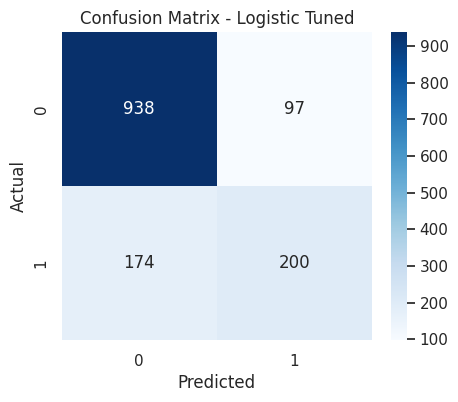

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# ============================================
# LOGISTIC TUNING
# ============================================

log_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

log_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=log_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

log_grid.fit(X_train_scaled, y_train)

print("Best Logistic Parameters:", log_grid.best_params_)

best_log = log_grid.best_estimator_


# Predictions
y_pred_log_tuned = best_log.predict(X_test_scaled)
y_prob_log_tuned = best_log.predict_proba(X_test_scaled)[:, 1]

print("\nTuned Logistic Regression")
print(classification_report(y_test, y_pred_log_tuned))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_log_tuned), 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log_tuned)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Tuned")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix_log_tuned.png")
plt.show()

Best Random Forest Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}

Tuned Random Forest
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1035
           1       0.67      0.40      0.50       374

    accuracy                           0.79      1409
   macro avg       0.74      0.67      0.68      1409
weighted avg       0.77      0.79      0.77      1409

ROC-AUC: 0.8407


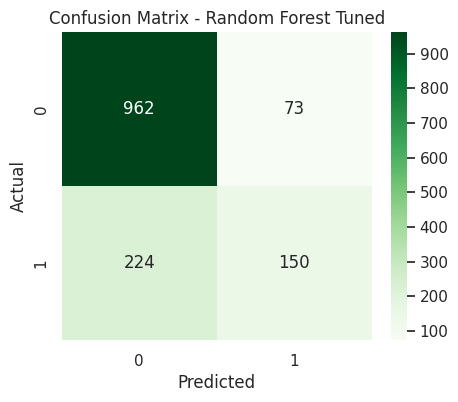

In [99]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# ============================================
# RANDOM FOREST TUNING
# ============================================

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)

best_rf = rf_grid.best_estimator_



# Predictions
y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print("\nTuned Random Forest")
print(classification_report(y_test, y_pred_rf_tuned))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf_tuned), 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest Tuned")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix_rf_tuned.png")
plt.show()

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}

Tuned XGBoost
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8458


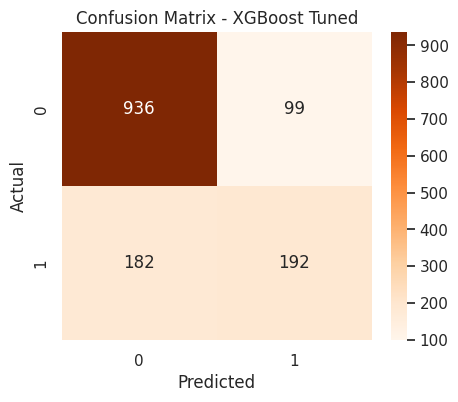

In [100]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# ============================================
# XGBOOST TUNING
# ============================================

xgb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=xgb_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost Parameters:", xgb_grid.best_params_)

best_xgb = xgb_grid.best_estimator_



# Predictions
y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("\nTuned XGBoost")
print(classification_report(y_test, y_pred_xgb_tuned))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb_tuned), 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb_tuned)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - XGBoost Tuned")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix_xgb_tuned.png")
plt.show()

In [101]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create comparison dictionary
comparison = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log_tuned),
        accuracy_score(y_test, y_pred_rf_tuned),
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log_tuned),
        precision_score(y_test, y_pred_rf_tuned),
        precision_score(y_test, y_pred_xgb_tuned)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log_tuned),
        recall_score(y_test, y_pred_rf_tuned),
        recall_score(y_test, y_pred_xgb_tuned)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log_tuned),
        f1_score(y_test, y_pred_rf_tuned),
        f1_score(y_test, y_pred_xgb_tuned)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log_tuned),
        roc_auc_score(y_test, y_prob_rf_tuned),
        roc_auc_score(y_test, y_prob_xgb_tuned)
    ]
}

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison)

# Round values
comparison_df.iloc[:, 1:] = comparison_df.iloc[:, 1:].round(4)

# Sort by best model (F1 or ROC-AUC)
comparison_df = comparison_df.sort_values(by="ROC-AUC", ascending=False)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8077,0.6734,0.5348,0.5961,0.8462
2,XGBoost,0.8006,0.6598,0.5134,0.5774,0.8458
1,Random Forest,0.7892,0.6726,0.4011,0.5025,0.8407


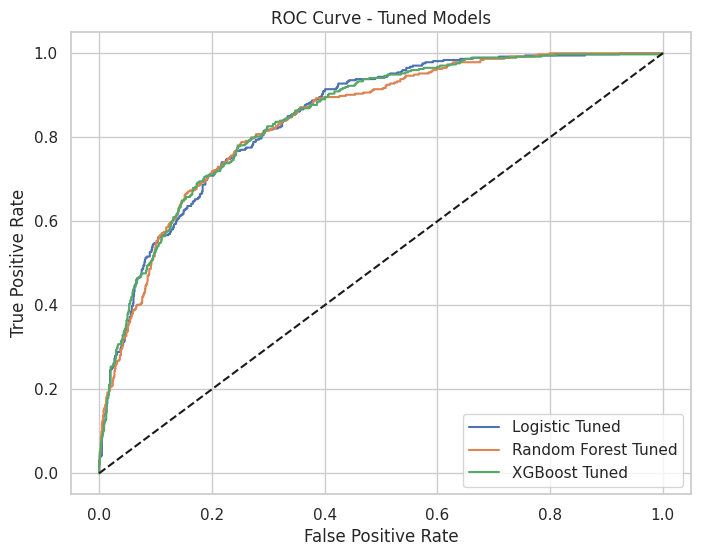

In [102]:
plt.figure(figsize=(8,6))

for name, model, scaled in [
    ("Logistic Tuned", best_log, True),
    ("Random Forest Tuned", best_rf, False),
    ("XGBoost Tuned", best_xgb, False)
]:
    if scaled:
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Models")
plt.legend()
plt.savefig("roc_curve_tuned.png")
plt.show()